**Load features and participant-level split**

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FEATURES_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "sleep_edf_features.csv"
)

PARTICIPANT_SPLIT_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "participant_split.csv"
)

df = pd.read_csv(
    FEATURES_PATH
)

participant_split_df = pd.read_csv(
    PARTICIPANT_SPLIT_PATH
)

df["participant_id"] = (
    df["subject_id"]
    .astype(str)
    .str[:5]
)

df = df.drop(
    columns=["split"],
    errors="ignore",
)

df = df.merge(
    participant_split_df[
        [
            "participant_id",
            "split",
        ]
    ],
    on="participant_id",
    how="inner",
    validate="many_to_one",
)

print(
    "Rows:",
    len(df),
)

print(
    "Recording IDs:",
    df["subject_id"].nunique(),
)

print(
    "Participants:",
    df["participant_id"].nunique(),
)

print(
    "\nSplit:"
)

print(
    df[
        [
            "participant_id",
            "split",
        ]
    ]
    .drop_duplicates()
    ["split"]
    .value_counts()
)

Rows: 457577
Recording IDs: 197
Participants: 100

Split:
split
train    70
val      15
test     15
Name: count, dtype: int64


**Final participant-level integrity check**

In [2]:
participant_split_check = (
    df[
        [
            "participant_id",
            "split",
        ]
    ]
    .drop_duplicates()
)

split_counts = (
    participant_split_check
    .groupby(
        "participant_id"
    )["split"]
    .nunique()
)

leaked = split_counts[
    split_counts > 1
]

print(
    "Participants appearing in multiple splits:",
    len(leaked),
)

assert len(leaked) == 0

print(
    "Participant leakage check: PASSED"
)

Participants appearing in multiple splits: 0
Participant leakage check: PASSED


**Build corrected train/validation/test dataframes**

In [3]:
train_df = (
    df[
        df["split"] == "train"
    ]
    .sort_values(
        [
            "subject_id",
            "epoch_index",
        ]
    )
    .reset_index(drop=True)
)

val_df = (
    df[
        df["split"] == "val"
    ]
    .sort_values(
        [
            "subject_id",
            "epoch_index",
        ]
    )
    .reset_index(drop=True)
)

test_df = (
    df[
        df["split"] == "test"
    ]
    .sort_values(
        [
            "subject_id",
            "epoch_index",
        ]
    )
    .reset_index(drop=True)
)

for name, frame in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df),
]:

    print(
        f"{name}: "
        f"{frame.shape[0]} epochs | "
        f"{frame['subject_id'].nunique()} recordings | "
        f"{frame['participant_id'].nunique()} participants"
    )

Train: 321688 epochs | 138 recordings | 70 participants
Validation: 65736 epochs | 29 recordings | 15 participants
Test: 70153 epochs | 30 recordings | 15 participants


**Corrected epoch distributions**

In [4]:
epoch_distribution = pd.crosstab(
    df["split"],
    df["target_stage"],
)

epoch_percentages = (
    epoch_distribution
    .div(
        epoch_distribution.sum(
            axis=1
        ),
        axis=0,
    )
    * 100
)

print("Epoch counts:")
display(epoch_distribution)

print("\nEpoch percentages:")
display(
    epoch_percentages.round(2)
)

Epoch counts:


target_stage,N1,N2,N3,REM,W
split,,,,,
test,4601,12657,2424,5613,44858
train,17180,62154,15014,23778,203562
val,3394,14172,2016,4793,41361



Epoch percentages:


target_stage,N1,N2,N3,REM,W
split,,,,,
test,6.56,18.04,3.46,8.00,63.94
train,5.34,19.32,4.67,7.39,63.28
val,5.16,21.56,3.07,7.29,62.92


**Epoch counts per participant**

In [5]:
participant_epoch_counts = (
    df.groupby(
        [
            "split",
            "participant_id",
        ]
    )
    .size()
    .rename("epochs")
)

print(
    participant_epoch_counts
    .groupby(level="split")
    .describe()
)

       count         mean          std     min      25%     50%     75%  \
split                                                                     
test    15.0  4676.866667  1439.602915  1731.0  5117.00  5372.0  5409.5   
train   70.0  4595.542857  1498.315476  1711.0  4777.75  5427.5  5524.5   
val     15.0  4382.400000  1642.122833  1894.0  2450.50  5410.0  5540.0   

          max  
split          
test   5559.0  
train  5760.0  
val    5690.0  


**Fit scaler ONLY on corrected training data**

In [6]:
from src.preprocessing.normalization import (
    SleepFeatureScaler,
)

feature_columns = [
    "delta_absolute",
    "theta_absolute",
    "alpha_absolute",
    "beta_absolute",
    "delta_relative",
    "theta_relative",
    "alpha_relative",
    "beta_relative",
    "spectral_entropy",
    "dominant_frequency",
]

corrected_scaler = SleepFeatureScaler()

X_train_scaled = (
    corrected_scaler.fit_transform(
        train_df
    )
)

X_val_scaled = (
    corrected_scaler.transform(
        val_df
    )
)

X_test_scaled = (
    corrected_scaler.transform(
        test_df
    )
)

print(
    "Train:",
    X_train_scaled.shape,
)

print(
    "Validation:",
    X_val_scaled.shape,
)

print(
    "Test:",
    X_test_scaled.shape,
)

Train: (321688, 10)
Validation: (65736, 10)
Test: (70153, 10)


**Verify no leakage through normalization**

In [7]:
print(
    "Training means:"
)

display(
    X_train_scaled.mean().round(6)
)

print(
    "\nTraining standard deviations:"
)

display(
    X_train_scaled.std().round(6)
)

print(
    "\nValidation means:"
)

display(
    X_val_scaled.mean().round(6)
)

print(
    "\nTest means:"
)

display(
    X_test_scaled.mean().round(6)
)

Training means:


delta_absolute        0.0
theta_absolute       -0.0
alpha_absolute        0.0
beta_absolute         0.0
delta_relative        0.0
theta_relative        0.0
alpha_relative       -0.0
beta_relative        -0.0
spectral_entropy      0.0
dominant_frequency   -0.0
dtype: float64


Training standard deviations:


delta_absolute        1.000002
theta_absolute        1.000002
alpha_absolute        1.000002
beta_absolute         1.000002
delta_relative        1.000002
theta_relative        1.000002
alpha_relative        1.000002
beta_relative         1.000002
spectral_entropy      1.000002
dominant_frequency    1.000002
dtype: float64


Validation means:


delta_absolute        0.087039
theta_absolute       -0.004665
alpha_absolute       -0.165109
beta_absolute        -0.175070
delta_relative        0.240733
theta_relative       -0.104406
alpha_relative       -0.201666
beta_relative        -0.218155
spectral_entropy     -0.240865
dominant_frequency   -0.013073
dtype: float64


Test means:


delta_absolute       -0.064232
theta_absolute       -0.157194
alpha_absolute       -0.198242
beta_absolute        -0.139685
delta_relative        0.095263
theta_relative       -0.093237
alpha_relative       -0.074924
beta_relative        -0.063341
spectral_entropy     -0.100550
dominant_frequency   -0.034827
dtype: float64

**Build corrected 20-epoch sequences**

In [8]:
from src.preprocessing.sequences import (
    build_sequences_from_dataframe,
    encode_sleep_stage_labels,
)

X_train_20, y_train_20_labels = (
    build_sequences_from_dataframe(
        dataframe=train_df,
        feature_values=X_train_scaled,
        sequence_length=20,
    )
)

X_val_20, y_val_20_labels = (
    build_sequences_from_dataframe(
        dataframe=val_df,
        feature_values=X_val_scaled,
        sequence_length=20,
    )
)

X_test_20, y_test_20_labels = (
    build_sequences_from_dataframe(
        dataframe=test_df,
        feature_values=X_test_scaled,
        sequence_length=20,
    )
)

y_train_20 = encode_sleep_stage_labels(
    y_train_20_labels
)

y_val_20 = encode_sleep_stage_labels(
    y_val_20_labels
)

y_test_20 = encode_sleep_stage_labels(
    y_test_20_labels
)

print(
    "Training:",
    X_train_20.shape,
    y_train_20.shape,
)

print(
    "Validation:",
    X_val_20.shape,
    y_val_20.shape,
)

print(
    "Test:",
    X_test_20.shape,
    y_test_20.shape,
)

Training: (316588, 20, 10) (316588,)
Validation: (64542, 20, 10) (64542,)
Test: (68908, 20, 10) (68908,)


**Verify the corrected sequence distributions**

In [9]:
for name, labels in [
    ("Train", y_train_20_labels),
    ("Validation", y_val_20_labels),
    ("Test", y_test_20_labels),
]:

    distribution = (
        pd.Series(labels)
        .value_counts()
        .reindex(
            [
                "W",
                "N1",
                "N2",
                "N3",
                "REM",
            ],
            fill_value=0,
        )
    )

    percentages = (
        distribution
        / distribution.sum()
        * 100
    )

    print(
        f"\n{name}"
    )
    print(
        "-" * 40
    )

    display(
        pd.DataFrame(
            {
                "count": distribution,
                "percentage":
                    percentages.round(2),
            }
        )
    )


Train
----------------------------------------


,count,percentage
W,200709,63.40
N1,16873,5.33
N2,60814,19.21
N3,14926,4.71
REM,23266,7.35



Validation
----------------------------------------


,count,percentage
W,40745,63.13
N1,3292,5.10
N2,13915,21.56
N3,2011,3.12
REM,4579,7.09



Test
----------------------------------------


,count,percentage
W,44249,64.21
N1,4467,6.48
N2,12386,17.97
N3,2419,3.51
REM,5387,7.82


**Verify the corrected sequences never cross participants**

In [10]:
def verify_sequence_boundaries(
    dataframe,
    sequence_length=20,
):
    violations = []

    for participant_id, participant_df in (
        dataframe.groupby(
            "participant_id",
            sort=False,
        )
    ):

        participant_df = (
            participant_df
            .sort_values(
                [
                    "subject_id",
                    "epoch_index",
                ]
            )
            .reset_index(drop=True)
        )

        # We only need to check recording boundaries.
        for subject_id, recording_df in (
            participant_df.groupby(
                "subject_id",
                sort=False,
            )
        ):

            recording_df = (
                recording_df
                .sort_values(
                    "epoch_index"
                )
                .reset_index(drop=True)
            )

            if len(recording_df) < sequence_length:
                continue

            # Sequence construction should stay inside
            # the same recording.
            for start in range(
                len(recording_df)
                - sequence_length
                + 1
            ):

                window = recording_df.iloc[
                    start:
                    start + sequence_length
                ]

                if (
                    window["subject_id"]
                    .nunique()
                    != 1
                    or
                    window["participant_id"]
                    .nunique()
                    != 1
                ):

                    violations.append(
                        (
                            participant_id,
                            subject_id,
                            start,
                        )
                    )

    return violations


boundary_violations = (
    verify_sequence_boundaries(
        df,
        sequence_length=20,
    )
)

print(
    "Sequence boundary violations:",
    len(boundary_violations),
)

assert len(boundary_violations) == 0

Sequence boundary violations: 0


**Seed reproducibility helper**

In [10]:
import random
import numpy as np
import tensorflow as tf


def set_experiment_seed(seed):
    """
    Reset Python, NumPy, and TensorFlow random states.
    """

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    print(
        f"Experiment seed set to {seed}"
    )

**Train stacked LSTM**

In [15]:
from src.models.lstm import (
    build_stacked_lstm,
    compile_baseline_lstm
)
from tensorflow import keras

def train_stacked_lstm(
    X_train,
    y_train,
    X_val,
    y_val,
    sequence_length,
    lstm_units=32,
):
    set_experiment_seed(42)

    model = build_stacked_lstm(
        sequence_length=sequence_length,
        n_features=10,
        n_classes=5,
        lstm_units=lstm_units,
        dropout_rate=0.30,
    )

    model = compile_baseline_lstm(
        model,
        learning_rate=1e-3,
    )

    train_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X_train,
                y_train,
            )
        )
        .shuffle(
            buffer_size=10000,
            seed=42,
            reshuffle_each_iteration=True,
        )
        .batch(256)
        .prefetch(tf.data.AUTOTUNE)
    )

    val_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X_val,
                y_val,
            )
        )
        .batch(256)
        .prefetch(tf.data.AUTOTUNE)
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        callbacks=callbacks,
        verbose=1,
    )

    return model, history

**Corrected development baseline**

In [16]:
# Step 16 — Corrected development baseline

set_experiment_seed(42)

corrected_baseline_model, corrected_baseline_history = (
    train_stacked_lstm(
        X_train=X_train_20,
        y_train=y_train_20,
        X_val=X_val_20,
        y_val=y_val_20,
        sequence_length=20,
        lstm_units=32,
    )
)

Experiment seed set to 42
Experiment seed set to 42
Epoch 1/30


d:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1237/1237 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - accuracy: 0.8412 - loss: 0.4336 - val_accuracy: 0.7632 - val_loss: 0.6157 - learning_rate: 0.0010
Epoch 2/30
1237/1237 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.8795 - loss: 0.3304 - val_accuracy: 0.7812 - val_loss: 0.5785 - learning_rate: 0.0010
Epoch 3/30
1237/1237 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.8900 - loss: 0.3019 - val_accuracy: 0.7733 - val_loss: 0.6379 - learning_rate: 0.0010
Epoch 4/30
1237/1237 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.8950 - loss: 0.2860 - val_accuracy: 0.8089 - val_loss: 0.5234 - learning_rate: 0.0010
Epoch 5/30
1237/1237 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.8993 - loss: 0.2755 - val_accuracy: 0.7973 - val_loss: 0.5865 - learning_rate: 0.0010
Epoch 6/30
1236/1237 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9012 - loss: 0.2679
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1237/1237 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.9011 - 

**Evaluation helper**

In [17]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)


def evaluate_model(
    model,
    X_test,
    y_test,
    model_name,
):
    test_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X_test,
                y_test,
            )
        )
        .batch(256)
        .prefetch(
            tf.data.AUTOTUNE
        )
    )

    probabilities = model.predict(
        test_ds,
        verbose=1,
    )

    predictions = np.argmax(
        probabilities,
        axis=1,
    )

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(
            y_test,
            predictions,
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y_test,
                predictions,
            )
        ),
        "macro_precision": (
            precision_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),
        "macro_recall": (
            recall_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),
        "macro_f1": (
            f1_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),
        "weighted_f1": (
            f1_score(
                y_test,
                predictions,
                average="weighted",
                zero_division=0,
            )
        ),
    }

    print(
        f"\n{model_name}"
    )

    for key, value in metrics.items():
        if key != "model":
            print(
                f"{key}: {value:.4f}"
            )

    return (
        metrics,
        predictions,
    )

**Validation evaluation only**

In [18]:
corrected_baseline_val_metrics, _ = (
    evaluate_model(
        corrected_baseline_model,
        X_val_20,
        y_val_20,
        "Corrected split — stacked LSTM(32+32)"
    )
)

253/253 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step

Corrected split — stacked LSTM(32+32)
accuracy: 0.8552
balanced_accuracy: 0.6873
macro_precision: 0.6945
macro_recall: 0.6873
macro_f1: 0.6907
weighted_f1: 0.8556


## CORRECTED PARTICIPANT-LEVEL MODEL SELECTION

**Imports and common configuration**

In [17]:
from pathlib import Path
import sys
import gc

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from tensorflow import keras

from src.models.lstm import (
    build_baseline_lstm,
    build_stacked_lstm,
    build_bidirectional_lstm,
    build_attention_lstm,
    compile_baseline_lstm,
)

from src.preprocessing.sequences import (
    build_sequences_from_dataframe,
    encode_sleep_stage_labels,
)

from src.preprocessing.normalization import (
    SleepFeatureScaler,
)


# ------------------------------------------------------------
# Project
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# ------------------------------------------------------------
# Constants
# ------------------------------------------------------------

FEATURE_COLUMNS = [
    "delta_absolute",
    "theta_absolute",
    "alpha_absolute",
    "beta_absolute",
    "delta_relative",
    "theta_relative",
    "alpha_relative",
    "beta_relative",
    "spectral_entropy",
    "dominant_frequency",
]

CLASS_NAMES = [
    "W",
    "N1",
    "N2",
    "N3",
    "REM",
]

N_FEATURES = len(FEATURE_COLUMNS)
N_CLASSES = len(CLASS_NAMES)

RANDOM_SEED = 42
BATCH_SIZE = 256
EPOCHS = 30

SEQUENCE_LENGTHS = [5, 10, 20]
LSTM_CAPACITIES = [32, 64, 128]


print("Features:", N_FEATURES)
print("Classes:", N_CLASSES)
print("Sequence lengths:", SEQUENCE_LENGTHS)
print("LSTM capacities:", LSTM_CAPACITIES)

Features: 10
Classes: 5
Sequence lengths: [5, 10, 20]
LSTM capacities: [32, 64, 128]


**Load the corrected participant-level dataset**

In [20]:
FEATURES_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "sleep_edf_features.csv"
)

PARTICIPANT_SPLIT_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "participant_split.csv"
)

df = pd.read_csv(
    FEATURES_PATH
)

participant_split_df = pd.read_csv(
    PARTICIPANT_SPLIT_PATH
)


# Derive participant ID explicitly.
df["participant_id"] = (
    df["subject_id"]
    .astype(str)
    .str[:5]
)


# Remove any previous split column.
df = df.drop(
    columns=["split"],
    errors="ignore",
)


# Attach participant-level split.
df = df.merge(
    participant_split_df[
        [
            "participant_id",
            "split",
        ]
    ],
    on="participant_id",
    how="inner",
    validate="many_to_one",
)


# Sort chronologically.
df = df.sort_values(
    [
        "subject_id",
        "epoch_index",
    ]
).reset_index(drop=True)


print(
    "Dataset shape:",
    df.shape,
)

print(
    "Recordings:",
    df["subject_id"].nunique(),
)

print(
    "Participants:",
    df["participant_id"].nunique(),
)

print(
    "\nParticipants by split:"
)

print(
    df[
        [
            "participant_id",
            "split",
        ]
    ]
    .drop_duplicates()
    ["split"]
    .value_counts()
)

Dataset shape: (457577, 18)
Recordings: 197
Participants: 100

Participants by split:
split
train    70
val      15
test     15
Name: count, dtype: int64


**Create corrected train/validation/test DataFrames**

In [10]:
train_df = (
    df[
        df["split"] == "train"
    ]
    .sort_values(
        [
            "subject_id",
            "epoch_index",
        ]
    )
    .reset_index(drop=True)
)

val_df = (
    df[
        df["split"] == "val"
    ]
    .sort_values(
        [
            "subject_id",
            "epoch_index",
        ]
    )
    .reset_index(drop=True)
)

test_df = (
    df[
        df["split"] == "test"
    ]
    .sort_values(
        [
            "subject_id",
            "epoch_index",
        ]
    )
    .reset_index(drop=True)
)


for name, frame in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df),
]:

    print(
        f"{name}:"
    )

    print(
        f"  Epochs: {len(frame)}"
    )

    print(
        f"  Recordings: "
        f"{frame['subject_id'].nunique()}"
    )

    print(
        f"  Participants: "
        f"{frame['participant_id'].nunique()}"
    )

    print()

Train:
  Epochs: 321688
  Recordings: 138
  Participants: 70

Validation:
  Epochs: 65736
  Recordings: 29
  Participants: 15

Test:
  Epochs: 70153
  Recordings: 30
  Participants: 15



**Fit the scaler ONLY on corrected training data**

In [23]:
# NORMALIZATION
scaler = SleepFeatureScaler()

X_train_scaled = (
    scaler.fit_transform(
        train_df
    )
)

X_val_scaled = (
    scaler.transform(
        val_df
    )
)

X_test_scaled = (
    scaler.transform(
        test_df
    )
)


print(
    "Train scaled:",
    X_train_scaled.shape,
)

print(
    "Validation scaled:",
    X_val_scaled.shape,
)

print(
    "Test scaled:",
    X_test_scaled.shape,
)


# Safety checks.

for name, values in [
    ("Train", X_train_scaled),
    ("Validation", X_val_scaled),
    ("Test", X_test_scaled),
]:

    numeric_values = (
        values.to_numpy(
            dtype=np.float64
        )
    )

    assert np.isfinite(
        numeric_values
    ).all(), (
        f"{name} contains "
        "NaN or infinite values."
    )


print(
    "\nNormalization checks passed."
)

Train scaled: (321688, 10)
Validation scaled: (65736, 10)
Test scaled: (70153, 10)

Normalization checks passed.


**Utility to build sequences**

In [13]:
def build_sequence_dataset(
    dataframe: pd.DataFrame,
    scaled_features: pd.DataFrame,
    sequence_length: int,
):
    """
    Build temporal sequences and encoded labels.
    """

    X, labels = (
        build_sequences_from_dataframe(
            dataframe=dataframe,
            feature_values=scaled_features,
            sequence_length=sequence_length,
        )
    )

    y = encode_sleep_stage_labels(
        labels
    )

    return X, y, labels


print(
    "Sequence builder ready."
)

Sequence builder ready.


**Train a single model**

In [19]:
def train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    loss_mode="unweighted",
    class_weights=None,
    seed=42,
):
    """
    Train one model using training and validation data only.
    """

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    set_experiment_seed(seed)

    # --------------------------------------------------------
    # Compile loss
    # --------------------------------------------------------

    if loss_mode == "unweighted":

        model = compile_baseline_lstm(
            model,
            learning_rate=1e-3,
        )

    elif loss_mode == "weighted":

        model.compile(
            optimizer=keras.optimizers.Adam(
                learning_rate=1e-3
            ),
            loss=(
                keras.losses.SparseCategoricalCrossentropy()
            ),
            metrics=[
                keras.metrics.SparseCategoricalAccuracy(
                    name="accuracy"
                )
            ],
        )

    elif loss_mode == "moderated":

        model.compile(
            optimizer=keras.optimizers.Adam(
                learning_rate=1e-3
            ),
            loss=(
                keras.losses.SparseCategoricalCrossentropy()
            ),
            metrics=[
                keras.metrics.SparseCategoricalAccuracy(
                    name="accuracy"
                )
            ],
        )

    else:

        raise ValueError(
            f"Unknown loss mode: {loss_mode}"
        )

    # --------------------------------------------------------
    # Datasets
    # --------------------------------------------------------

    train_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X_train,
                y_train,
            )
        )
        .shuffle(
            buffer_size=10000,
            seed=seed,
            reshuffle_each_iteration=True,
        )
        .batch(
            BATCH_SIZE
        )
        .prefetch(
            tf.data.AUTOTUNE
        )
    )

    val_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X_val,
                y_val,
            )
        )
        .batch(
            BATCH_SIZE
        )
        .prefetch(
            tf.data.AUTOTUNE
        )
    )

    # --------------------------------------------------------
    # Callbacks
    # --------------------------------------------------------

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1,
        ),

        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    # --------------------------------------------------------
    # class weights
    # --------------------------------------------------------

    fit_kwargs = {}

    if (
        loss_mode in [
            "weighted",
            "moderated",
        ]
        and class_weights is not None
    ):

        fit_kwargs["class_weight"] = (
            class_weights
        )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        shuffle=False,
        verbose=1,
        **fit_kwargs,
    )

    return model, history

**Evaluation helper**

In [21]:
def evaluate_validation(
    model,
    X,
    y,
):
    """
    Evaluate a model without using the test set.
    """

    probabilities = (
        model.predict(
            X,
            batch_size=BATCH_SIZE,
            verbose=0,
        )
    )

    predictions = np.argmax(
        probabilities,
        axis=1,
    )

    metrics = {
        "accuracy": accuracy_score(
            y,
            predictions,
        ),

        "balanced_accuracy": (
            balanced_accuracy_score(
                y,
                predictions,
            )
        ),

        "macro_precision": (
            precision_score(
                y,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),

        "macro_recall": (
            recall_score(
                y,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),

        "macro_f1": (
            f1_score(
                y,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),

        "weighted_f1": (
            f1_score(
                y,
                predictions,
                average="weighted",
                zero_division=0,
            )
        ),
    }

    return metrics

**Recreate class weights**

In [27]:
# CORRECTED CLASS WEIGHTS
from sklearn.utils.class_weight import (
    compute_class_weight,
)


# We'll start with the 20-epoch sequences because
# that was the strongest context previously.
#
# These are NOT final yet. They are only used to
# construct the loss-selection candidates.

X_train_20_tmp, y_train_20_tmp, _ = (
    build_sequence_dataset(
        train_df,
        X_train_scaled,
        20,
    )
)

classes = np.arange(
    N_CLASSES
)

balanced_weights_array = (
    compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train_20_tmp,
    )
)

balanced_class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(
        classes,
        balanced_weights_array,
    )
}

moderated_class_weights = {
    class_id: float(
        np.sqrt(weight)
    )
    for class_id, weight
    in balanced_class_weights.items()
}

print(
    "Balanced class weights:"
)

print(
    balanced_class_weights
)

print(
    "\nModerated class weights:"
)

print(
    moderated_class_weights
)

Balanced class weights:
{0: 0.31546966005510463, 1: 3.7525988265275885, 2: 1.041168152070247, 3: 4.2421010317566665, 4: 2.721464798418293}

Moderated class weights:
{0: 0.5616668586049071, 1: 1.9371625710114235, 2: 1.0203764756550628, 3: 2.059636140622092, 4: 1.6496862727253}


**Experiment 1: Temporal-context selection**

In [22]:
# EXPERIMENT 1
# TEMPORAL-CONTEXT SELECTION

temporal_results = []

temporal_models = {}
temporal_histories = {}

for sequence_length in SEQUENCE_LENGTHS:

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"TEMPORAL CONTEXT: "
        f"{sequence_length} epochs"
    )

    print(
        "=" * 70
    )

    # --------------------------------------------------------
    # Sequences
    # --------------------------------------------------------

    X_train_seq, y_train_seq, _ = (
        build_sequence_dataset(
            train_df,
            X_train_scaled,
            sequence_length,
        )
    )

    X_val_seq, y_val_seq, _ = (
        build_sequence_dataset(
            val_df,
            X_val_scaled,
            sequence_length,
        )
    )

    print(
        "Training:",
        X_train_seq.shape,
    )

    print(
        "Validation:",
        X_val_seq.shape,
    )

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = build_baseline_lstm(
        sequence_length=sequence_length,
        n_features=N_FEATURES,
        n_classes=N_CLASSES,
        lstm_units=32,
        dropout_rate=0.30,
    )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model, history = train_model(
        model=model,
        X_train=X_train_seq,
        y_train=y_train_seq,
        X_val=X_val_seq,
        y_val=y_val_seq,
        loss_mode="unweighted",
        seed=RANDOM_SEED,
    )

    # --------------------------------------------------------
    # Validation only
    # --------------------------------------------------------

    metrics = evaluate_validation(
        model,
        X_val_seq,
        y_val_seq,
    )

    metrics[
        "sequence_length"
    ] = sequence_length

    metrics[
        "context_minutes"
    ] = (
        sequence_length * 0.5
    )

    temporal_results.append(
        metrics
    )

    temporal_models[
        sequence_length
    ] = model

    temporal_histories[
        sequence_length
    ] = history

    print(
        "\nValidation metrics:"
    )

    print(
        pd.Series(
            metrics
        ).round(4)
    )

    # --------------------------------------------------------
    # Memory cleanup
    # --------------------------------------------------------

    del (
        X_train_seq,
        y_train_seq,
        X_val_seq,
        y_val_seq,
    )

    gc.collect()


TEMPORAL CONTEXT: 5 epochs
Training: (320586, 5, 10)
Validation: (65455, 5, 10)
Experiment seed set to 42
Epoch 1/30
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8007 - loss: 0.5349 - val_accuracy: 0.6881 - val_loss: 0.7801 - learning_rate: 0.0010
Epoch 2/30
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8409 - loss: 0.4276 - val_accuracy: 0.7016 - val_loss: 0.7504 - learning_rate: 0.0010
Epoch 3/30
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8477 - loss: 0.4113 - val_accuracy: 0.7215 - val_loss: 0.7017 - learning_rate: 0.0010
Epoch 4/30
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8517 - loss: 0.4008 - val_accuracy: 0.7361 - val_loss: 0.6800 - learning_rate: 0.0010
Epoch 5/30
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8548 - loss: 0.3934 - val_accuracy: 0.7366 - val_loss: 0.6750 - learning_rate: 0.0010
Epoch 6/30
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8567 - loss: 0.3876 - val_accuracy: 0.7382 - val_loss: 

**Select the best temporal context**

In [23]:
temporal_results_df = (
    pd.DataFrame(
        temporal_results
    )
    .sort_values(
        "macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "Temporal-context results:"
)

display(
    temporal_results_df.round(4)
)

BEST_SEQUENCE_LENGTH = int(
    temporal_results_df.iloc[0][
        "sequence_length"
    ]
)

print(
    "\nSelected sequence length:",
    BEST_SEQUENCE_LENGTH,
)

print(
    "Selected context:",
    BEST_SEQUENCE_LENGTH * 0.5,
    "minutes",
)

Temporal-context results:


,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,sequence_length,context_minutes
0,0.8497,0.6824,0.6742,0.6824,0.6749,0.8468,10,5.0
1,0.8513,0.6828,0.6648,0.6828,0.6733,0.8522,20,10.0
2,0.8352,0.6497,0.6532,0.6497,0.6443,0.8281,5,2.5



Selected sequence length: 10
Selected context: 5.0 minutes


**Rebuild the selected temporal context**

In [24]:
X_train_best, y_train_best, y_train_best_labels = (
    build_sequence_dataset(
        train_df,
        X_train_scaled,
        BEST_SEQUENCE_LENGTH,
    )
)

X_val_best, y_val_best, y_val_best_labels = (
    build_sequence_dataset(
        val_df,
        X_val_scaled,
        BEST_SEQUENCE_LENGTH,
    )
)

X_test_best, y_test_best, y_test_best_labels = (
    build_sequence_dataset(
        test_df,
        X_test_scaled,
        BEST_SEQUENCE_LENGTH,
    )
)

print(
    "Selected sequence length:",
    BEST_SEQUENCE_LENGTH,
)

print(
    "\nTrain:",
    X_train_best.shape,
    y_train_best.shape,
)

print(
    "Validation:",
    X_val_best.shape,
    y_val_best.shape,
)

print(
    "Test:",
    X_test_best.shape,
    y_test_best.shape,
)

Selected sequence length: 10

Train: (319226, 10, 10) (319226,)
Validation: (65133, 10, 10) (65133,)
Test: (69539, 10, 10) (69539,)


**Recalculate class weights for selected context**

In [31]:
balanced_weights_array = (
    compute_class_weight(
        class_weight="balanced",
        classes=np.arange(
            N_CLASSES
        ),
        y=y_train_best,
    )
)

balanced_class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(
        np.arange(N_CLASSES),
        balanced_weights_array,
    )
}

moderated_class_weights = {
    class_id: float(
        np.sqrt(weight)
    )
    for class_id, weight
    in balanced_class_weights.items()
}

print(
    "Balanced:"
)

print(
    balanced_class_weights
)

print(
    "\nModerated:"
)

print(
    moderated_class_weights
)

Balanced:
{0: 0.31580269874559774, 1: 3.7591380122468205, 2: 1.0374754220900566, 3: 4.26146041916967, 4: 2.7107035197214793}

Moderated:
{0: 0.5619632539104294, 1: 1.938849662105554, 2: 1.0185653744802328, 3: 2.0643305014385827, 4: 1.646421428347396}


**Experiment 2: Loss selection**

In [33]:
# EXPERIMENT 2
# LOSS SELECTION

loss_candidates = {
    "weighted": balanced_class_weights,
    "moderated": moderated_class_weights,
    "unweighted": None,
}

loss_results = []

loss_models = {}
loss_histories = {}

for loss_name, weights in (
    loss_candidates.items()
):

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"LOSS STRATEGY: {loss_name}"
    )

    print(
        "=" * 70
    )

    model = build_baseline_lstm(
        sequence_length=BEST_SEQUENCE_LENGTH,
        n_features=N_FEATURES,
        n_classes=N_CLASSES,
        lstm_units=32,
        dropout_rate=0.30,
    )

    model, history = train_model(
        model=model,
        X_train=X_train_best,
        y_train=y_train_best,
        X_val=X_val_best,
        y_val=y_val_best,
        loss_mode=loss_name,
        class_weights=weights,
        seed=RANDOM_SEED,
    )

    metrics = evaluate_validation(
        model,
        X_val_best,
        y_val_best,
    )

    metrics[
        "loss_strategy"
    ] = loss_name

    loss_results.append(
        metrics
    )

    loss_models[
        loss_name
    ] = model

    loss_histories[
        loss_name
    ] = history

    print(
        "\nValidation metrics:"
    )

    print(
        pd.Series({
            key: round(value, 4) if isinstance(value, (int, float)) else value
            for key, value in metrics.items()
        })
    )


LOSS STRATEGY: weighted
Experiment seed set to 42
Epoch 1/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7498 - loss: 0.7285 - val_accuracy: 0.5702 - val_loss: 1.2091 - learning_rate: 0.0010
Epoch 2/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8001 - loss: 0.6197 - val_accuracy: 0.6062 - val_loss: 1.1115 - learning_rate: 0.0010
Epoch 3/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8104 - loss: 0.5916 - val_accuracy: 0.6244 - val_loss: 1.0715 - learning_rate: 0.0010
Epoch 4/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8171 - loss: 0.5715 - val_accuracy: 0.6530 - val_loss: 0.9703 - learning_rate: 0.0010
Epoch 5/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8212 - loss: 0.5587 - val_accuracy: 0.6442 - val_loss: 1.0237 - learning_rate: 0.0010
Epoch 6/30
1244/1247 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8240 - loss: 0.5521
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1247/1247 

**Select loss strategy**

In [34]:
loss_results_df = (
    pd.DataFrame(
        loss_results
    )
    .sort_values(
        "macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "Loss-selection results:"
)

display(
    loss_results_df.round(4)
)

BEST_LOSS = (
    loss_results_df.iloc[0][
        "loss_strategy"
    ]
)

print(
    "\nSelected loss strategy:",
    BEST_LOSS,
)

Loss-selection results:


,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,loss_strategy
0,0.8497,0.6824,0.6742,0.6824,0.6749,0.8468,unweighted
1,0.8278,0.7283,0.6392,0.7283,0.6701,0.8384,moderated
2,0.7917,0.7510,0.6177,0.7510,0.6428,0.8146,weighted



Selected loss strategy: unweighted


**Experiment 3: LSTM capacity selection**

In [35]:
# EXPERIMENT 3
# LSTM CAPACITY SELECTION

if BEST_LOSS == "weighted":

    selected_class_weights = (
        balanced_class_weights
    )

elif BEST_LOSS == "moderated":

    selected_class_weights = (
        moderated_class_weights
    )

else:

    selected_class_weights = None


capacity_results = []

capacity_models = {}
capacity_histories = {}

for units in LSTM_CAPACITIES:

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"LSTM CAPACITY: {units} units"
    )

    print(
        "=" * 70
    )

    model = build_baseline_lstm(
        sequence_length=BEST_SEQUENCE_LENGTH,
        n_features=N_FEATURES,
        n_classes=N_CLASSES,
        lstm_units=units,
        dropout_rate=0.30,
    )

    model, history = train_model(
        model=model,
        X_train=X_train_best,
        y_train=y_train_best,
        X_val=X_val_best,
        y_val=y_val_best,
        loss_mode=BEST_LOSS,
        class_weights=selected_class_weights,
        seed=RANDOM_SEED,
    )

    metrics = evaluate_validation(
        model,
        X_val_best,
        y_val_best,
    )

    metrics[
        "lstm_units"
    ] = units

    capacity_results.append(
        metrics
    )

    capacity_models[
        units
    ] = model

    capacity_histories[
        units
    ] = history

    print(
        "\nValidation metrics:"
    )

    print(
        pd.Series(
            metrics
        ).round(4)
    )


LSTM CAPACITY: 32 units
Experiment seed set to 42
Epoch 1/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8186 - loss: 0.4878 - val_accuracy: 0.7157 - val_loss: 0.7113 - learning_rate: 0.0010
Epoch 2/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8589 - loss: 0.3800 - val_accuracy: 0.7350 - val_loss: 0.6580 - learning_rate: 0.0010
Epoch 3/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8666 - loss: 0.3615 - val_accuracy: 0.7635 - val_loss: 0.5997 - learning_rate: 0.0010
Epoch 4/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8724 - loss: 0.3473 - val_accuracy: 0.7839 - val_loss: 0.5529 - learning_rate: 0.0010
Epoch 5/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8759 - loss: 0.3377 - val_accuracy: 0.7874 - val_loss: 0.5528 - learning_rate: 0.0010
Epoch 6/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8779 - loss: 0.3318 - val_accuracy: 0.7963 - val_loss: 0.5314 - learning_rate: 0.0010
Epoch 7/30
1247/1247 ━━

**Select LSTM capacity**

In [36]:
capacity_results_df = (
    pd.DataFrame(
        capacity_results
    )
    .sort_values(
        "macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "Capacity-selection results:"
)

display(
    capacity_results_df.round(4)
)

BEST_LSTM_UNITS = int(
    capacity_results_df.iloc[0][
        "lstm_units"
    ]
)

print(
    "\nSelected LSTM units:",
    BEST_LSTM_UNITS,
)

Capacity-selection results:


,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,lstm_units
0,0.8497,0.6824,0.6742,0.6824,0.6749,0.8468,32
1,0.8458,0.6774,0.6724,0.6774,0.6721,0.8426,64
2,0.8161,0.6582,0.6242,0.6582,0.6393,0.8196,128



Selected LSTM units: 32


**Experiment 4: Architecture selection**

In [38]:
# EXPERIMENT 4
# ARCHITECTURE SELECTION

def build_architecture(
    architecture_name,
):
    """
    Build one candidate architecture with all
    other hyperparameters frozen.
    """

    if architecture_name == "single":

        return build_baseline_lstm(
            sequence_length=BEST_SEQUENCE_LENGTH,
            n_features=N_FEATURES,
            n_classes=N_CLASSES,
            lstm_units=BEST_LSTM_UNITS,
            dropout_rate=0.30,
        )

    if architecture_name == "stacked":

        return build_stacked_lstm(
            sequence_length=BEST_SEQUENCE_LENGTH,
            n_features=N_FEATURES,
            n_classes=N_CLASSES,
            lstm_units=BEST_LSTM_UNITS,
            dropout_rate=0.30,
        )

    if architecture_name == "bidirectional":

        return build_bidirectional_lstm(
            sequence_length=BEST_SEQUENCE_LENGTH,
            n_features=N_FEATURES,
            n_classes=N_CLASSES,
            lstm_units=BEST_LSTM_UNITS,
            dropout_rate=0.30,
        )

    if architecture_name == "attention":

        return build_attention_lstm(
            sequence_length=BEST_SEQUENCE_LENGTH,
            n_features=N_FEATURES,
            n_classes=N_CLASSES,
            lstm_units=BEST_LSTM_UNITS,
            dropout_rate=0.30,
        )

    raise ValueError(
        f"Unknown architecture: "
        f"{architecture_name}"
    )


ARCHITECTURES = [
    "single",
    "stacked",
    "bidirectional",
    "attention",
]

architecture_results = []

architecture_models = {}
architecture_histories = {}


for architecture_name in ARCHITECTURES:

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"ARCHITECTURE: "
        f"{architecture_name}"
    )

    print(
        "=" * 70
    )

    model = build_architecture(
        architecture_name
    )

    model, history = train_model(
        model=model,
        X_train=X_train_best,
        y_train=y_train_best,
        X_val=X_val_best,
        y_val=y_val_best,
        loss_mode=BEST_LOSS,
        class_weights=selected_class_weights,
        seed=RANDOM_SEED,
    )

    metrics = evaluate_validation(
        model,
        X_val_best,
        y_val_best,
    )

    metrics[
        "architecture"
    ] = architecture_name

    architecture_results.append(
        metrics
    )

    architecture_models[
        architecture_name
    ] = model

    architecture_histories[
        architecture_name
    ] = history

    print(
        "\nValidation metrics:"
    )

    print(
        pd.Series({
            key: round(value, 4) if isinstance(value, (int, float)) else value
            for key, value in metrics.items()
        })
    )


ARCHITECTURE: single
Experiment seed set to 42
Epoch 1/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8186 - loss: 0.4878 - val_accuracy: 0.7157 - val_loss: 0.7113 - learning_rate: 0.0010
Epoch 2/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8589 - loss: 0.3800 - val_accuracy: 0.7350 - val_loss: 0.6580 - learning_rate: 0.0010
Epoch 3/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8666 - loss: 0.3615 - val_accuracy: 0.7635 - val_loss: 0.5997 - learning_rate: 0.0010
Epoch 4/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8724 - loss: 0.3473 - val_accuracy: 0.7839 - val_loss: 0.5529 - learning_rate: 0.0010
Epoch 5/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8759 - loss: 0.3377 - val_accuracy: 0.7874 - val_loss: 0.5528 - learning_rate: 0.0010
Epoch 6/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8779 - loss: 0.3318 - val_accuracy: 0.7963 - val_loss: 0.5314 - learning_rate: 0.0010
Epoch 7/30
1247/1247 ━

**Select final architecture**

In [39]:
architecture_results_df = (
    pd.DataFrame(
        architecture_results
    )
    .sort_values(
        "macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "Architecture-selection results:"
)

display(
    architecture_results_df.round(4)
)

BEST_ARCHITECTURE = (
    architecture_results_df.iloc[0][
        "architecture"
    ]
)

print(
    "\nSelected architecture:",
    BEST_ARCHITECTURE,
)

Architecture-selection results:


,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,architecture
0,0.8577,0.6875,0.6961,0.6875,0.6869,0.8519,stacked
1,0.8497,0.6824,0.6742,0.6824,0.6749,0.8468,single
2,0.8401,0.6760,0.6553,0.6760,0.6627,0.8396,attention
3,0.8324,0.6681,0.6451,0.6681,0.6554,0.8334,bidirectional



Selected architecture: stacked


**FINAL SELECTED CONFIGURATION**

In [40]:
FINAL_SELECTED_CONFIG = {
    "sequence_length_epochs":
        BEST_SEQUENCE_LENGTH,

    "temporal_context_minutes":
        BEST_SEQUENCE_LENGTH * 0.5,

    "loss_strategy":
        BEST_LOSS,

    "lstm_units":
        BEST_LSTM_UNITS,

    "architecture":
        BEST_ARCHITECTURE,

    "dropout":
        0.30,

    "n_features":
        N_FEATURES,

    "n_classes":
        N_CLASSES,

    "features":
        FEATURE_COLUMNS,

    "classes":
        CLASS_NAMES,

    "random_seed":
        RANDOM_SEED,

    "batch_size":
        BATCH_SIZE,
}

print(
    "=" * 70
)

print(
    "SELECTED CONFIGURATION"
)

print(
    "=" * 70
)

for key, value in (
    FINAL_SELECTED_CONFIG.items()
):

    print(
        f"{key}: {value}"
    )

SELECTED CONFIGURATION
sequence_length_epochs: 10
temporal_context_minutes: 5.0
loss_strategy: unweighted
lstm_units: 32
architecture: stacked
dropout: 0.3
n_features: 10
n_classes: 5
features: ['delta_absolute', 'theta_absolute', 'alpha_absolute', 'beta_absolute', 'delta_relative', 'theta_relative', 'alpha_relative', 'beta_relative', 'spectral_entropy', 'dominant_frequency']
classes: ['W', 'N1', 'N2', 'N3', 'REM']
random_seed: 42
batch_size: 256


**Save model-selection results**

In [41]:
SELECTION_DIR = (
    PROJECT_ROOT
    / "results"
    / "corrected_model_selection"
)

SELECTION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


temporal_results_df.to_csv(
    SELECTION_DIR
    / "temporal_context_selection.csv",
    index=False,
)

loss_results_df.to_csv(
    SELECTION_DIR
    / "loss_selection.csv",
    index=False,
)

capacity_results_df.to_csv(
    SELECTION_DIR
    / "capacity_selection.csv",
    index=False,
)

architecture_results_df.to_csv(
    SELECTION_DIR
    / "architecture_selection.csv",
    index=False,
)


import json

with open(
    SELECTION_DIR
    / "selected_configuration.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        FINAL_SELECTED_CONFIG,
        file,
        indent=4,
    )


print(
    "Selection results saved to:"
)

print(
    SELECTION_DIR
)

Selection results saved to:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\results\corrected_model_selection


**Build the selected model from scratch**

In [42]:
FINAL_MODEL = build_architecture(
    BEST_ARCHITECTURE
)

FINAL_MODEL.summary()

Model: "stacked_sleep_stage_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_features (InputLayer)       │ (None, 10, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 32)         │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sleep_stage (Dense)             │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,989 (54.64 KB)

 Trainable params: 13,989 (54.64 KB)

 Non-trainable params: 0 (0.00 B)

**TRAIN FRESH SELECTED MODEL**

In [43]:
FINAL_MODEL, FINAL_HISTORY = train_model(
    model=FINAL_MODEL,
    X_train=X_train_best,
    y_train=y_train_best,
    X_val=X_val_best,
    y_val=y_val_best,
    loss_mode=BEST_LOSS,
    class_weights=selected_class_weights,
    seed=RANDOM_SEED,
)

Experiment seed set to 42
Epoch 1/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.8318 - loss: 0.4577 - val_accuracy: 0.7189 - val_loss: 0.7221 - learning_rate: 0.0010
Epoch 2/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8670 - loss: 0.3625 - val_accuracy: 0.7308 - val_loss: 0.6992 - learning_rate: 0.0010
Epoch 3/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8757 - loss: 0.3386 - val_accuracy: 0.7656 - val_loss: 0.6136 - learning_rate: 0.0010
Epoch 4/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8810 - loss: 0.3239 - val_accuracy: 0.7799 - val_loss: 0.5817 - learning_rate: 0.0010
Epoch 5/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8843 - loss: 0.3129 - val_accuracy: 0.7676 - val_loss: 0.6319 - learning_rate: 0.0010
Epoch 6/30
1246/1247 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8861 - loss: 0.3064
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1247/1247 ━━━━━━━━━━━━━━━━━━━

**Final model — validation sanity check**

In [44]:
final_validation_metrics = (
    evaluate_validation(
        FINAL_MODEL,
        X_val_best,
        y_val_best,
    )
)

print(
    "Final model validation metrics:"
)

print(
    pd.Series(
        final_validation_metrics
    ).round(4)
)

Final model validation metrics:
accuracy             0.8577
balanced_accuracy    0.6875
macro_precision      0.6961
macro_recall         0.6875
macro_f1             0.6869
weighted_f1          0.8519
dtype: float64


**Final test evaluation**

In [45]:
test_probabilities = (
    FINAL_MODEL.predict(
        X_test_best,
        batch_size=BATCH_SIZE,
        verbose=1,
    )
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1,
)


FINAL_TEST_METRICS = {
    "accuracy": accuracy_score(
        y_test_best,
        test_predictions,
    ),

    "balanced_accuracy": (
        balanced_accuracy_score(
            y_test_best,
            test_predictions,
        )
    ),

    "macro_precision": (
        precision_score(
            y_test_best,
            test_predictions,
            average="macro",
            zero_division=0,
        )
    ),

    "macro_recall": (
        recall_score(
            y_test_best,
            test_predictions,
            average="macro",
            zero_division=0,
        )
    ),

    "macro_f1": (
        f1_score(
            y_test_best,
            test_predictions,
            average="macro",
            zero_division=0,
        )
    ),

    "weighted_f1": (
        f1_score(
            y_test_best,
            test_predictions,
            average="weighted",
            zero_division=0,
        )
    ),
}


print(
    "=" * 70
)

print(
    "FINAL TEST RESULTS"
)

print(
    "=" * 70
)

for key, value in (
    FINAL_TEST_METRICS.items()
):

    print(
        f"{key}: {value:.4f}"
    )

272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
FINAL TEST RESULTS
accuracy: 0.8266
balanced_accuracy: 0.6517
macro_precision: 0.6706
macro_recall: 0.6517
macro_f1: 0.6534
weighted_f1: 0.8245


**Final classification report**

In [46]:
from sklearn.metrics import (
    classification_report,
)

print(
    classification_report(
        y_test_best,
        test_predictions,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

           W     0.9622    0.9353    0.9485     44556
          N1     0.4683    0.2634    0.3372      4522
          N2     0.6348    0.7758    0.6982     12545
          N3     0.7694    0.7052    0.7359      2422
         REM     0.5185    0.5790    0.5471      5494

    accuracy                         0.8266     69539
   macro avg     0.6706    0.6517    0.6534     69539
weighted avg     0.8292    0.8266    0.8245     69539



**Final confusion matrix**

Final confusion matrix:
[[41671   673  1458    80   674]
 [  590  1191  1826    34   881]
 [  619   425  9732   384  1385]
 [   50     0   650  1708    14]
 [  380   254  1665    14  3181]]


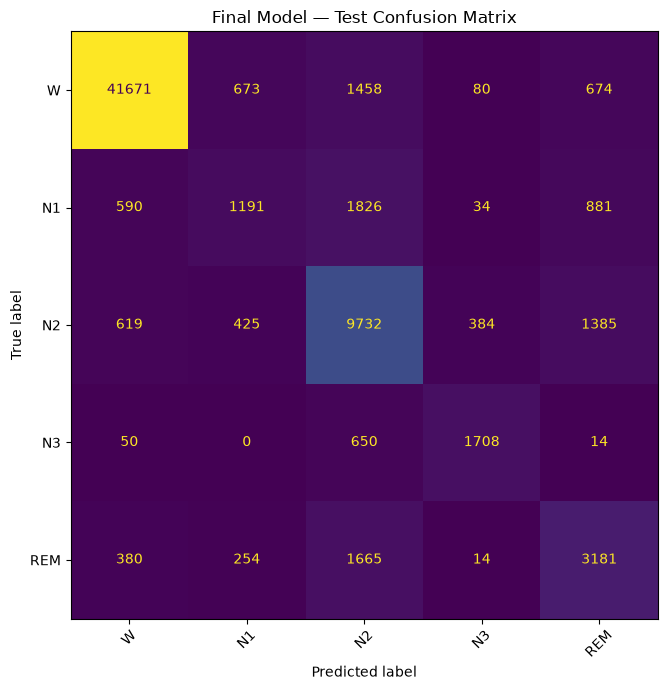

In [47]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt


FINAL_CONFUSION_MATRIX = (
    confusion_matrix(
        y_test_best,
        test_predictions,
    )
)

print(
    "Final confusion matrix:"
)

print(
    FINAL_CONFUSION_MATRIX
)


display_matrix = (
    ConfusionMatrixDisplay(
        confusion_matrix=
            FINAL_CONFUSION_MATRIX,
        display_labels=CLASS_NAMES,
    )
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

display_matrix.plot(
    ax=ax,
    values_format="d",
    xticks_rotation=45,
    colorbar=False,
)

ax.set_title(
    "Final Model — Test Confusion Matrix"
)

plt.tight_layout()
plt.show()

**Save the corrected final model**

In [48]:
FINAL_MODEL_DIR = (
    PROJECT_ROOT
    / "final_model_corrected"
)

FINAL_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


FINAL_MODEL_PATH = (
    FINAL_MODEL_DIR
    / "stacked_lstm_final.keras"
)

FINAL_MODEL.save(
    FINAL_MODEL_PATH
)


# Configuration

FINAL_CONFIG_PATH = (
    FINAL_MODEL_DIR
    / "config.json"
)

with open(
    FINAL_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        FINAL_SELECTED_CONFIG,
        file,
        indent=4,
    )


# Test metrics

FINAL_METRICS_PATH = (
    FINAL_MODEL_DIR
    / "test_metrics.csv"
)

pd.DataFrame(
    [FINAL_TEST_METRICS]
).to_csv(
    FINAL_METRICS_PATH,
    index=False,
)


# Confusion matrix

pd.DataFrame(
    FINAL_CONFUSION_MATRIX,
    index=CLASS_NAMES,
    columns=CLASS_NAMES,
).to_csv(
    FINAL_MODEL_DIR
    / "confusion_matrix.csv"
)


# Training history

pd.DataFrame(
    FINAL_HISTORY.history
).to_csv(
    FINAL_MODEL_DIR
    / "training_history.csv",
    index=False,
)


print(
    "Corrected final model saved to:"
)

print(
    FINAL_MODEL_DIR
)

Corrected final model saved to:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\final_model_corrected


**Save the corrected scaler**

In [49]:
import joblib

CORRECTED_SCALER_PATH = (
    FINAL_MODEL_DIR
    / "scaler.pkl"
)

joblib.dump(
    scaler,
    CORRECTED_SCALER_PATH,
)

print(
    "Corrected scaler saved to:"
)

print(
    CORRECTED_SCALER_PATH
)

Corrected scaler saved to:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\final_model_corrected\scaler.pkl


**Save the participant split with the final model**

In [50]:
participant_split_df.to_csv(
    FINAL_MODEL_DIR
    / "participant_split.csv",
    index=False,
)

print(
    "Participant split saved."
)

Participant split saved.


**Final experiment summary**

In [51]:
print(
    "=" * 80
)

print(
    "CORRECTED MODEL-DEVELOPMENT SUMMARY"
)

print(
    "=" * 80
)

print(
    "\nTemporal context:"
)

display(
    temporal_results_df[
        [
            "sequence_length",
            "context_minutes",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
        ]
    ].round(4)
)

print(
    "\nLoss strategy:"
)

display(
    loss_results_df[
        [
            "loss_strategy",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
        ]
    ].round(4)
)

print(
    "\nLSTM capacity:"
)

display(
    capacity_results_df[
        [
            "lstm_units",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
        ]
    ].round(4)
)

print(
    "\nArchitecture:"
)

display(
    architecture_results_df[
        [
            "architecture",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
        ]
    ].round(4)
)

print(
    "\nFinal selected configuration:"
)

print(
    json.dumps(
        FINAL_SELECTED_CONFIG,
        indent=4,
    )
)

print(
    "\nFinal test metrics:"
)

print(
    pd.Series(
        FINAL_TEST_METRICS
    ).round(4)
)

CORRECTED MODEL-DEVELOPMENT SUMMARY

Temporal context:


,sequence_length,context_minutes,accuracy,balanced_accuracy,macro_f1
0,10,5.0,0.8497,0.6824,0.6749
1,20,10.0,0.8513,0.6828,0.6733
2,5,2.5,0.8292,0.6572,0.6366



Loss strategy:


,loss_strategy,accuracy,balanced_accuracy,macro_f1
0,unweighted,0.8497,0.6824,0.6749
1,moderated,0.8278,0.7283,0.6701
2,weighted,0.7917,0.7510,0.6428



LSTM capacity:


,lstm_units,accuracy,balanced_accuracy,macro_f1
0,32,0.8497,0.6824,0.6749
1,64,0.8458,0.6774,0.6721
2,128,0.8161,0.6582,0.6393



Architecture:


,architecture,accuracy,balanced_accuracy,macro_f1
0,stacked,0.8577,0.6875,0.6869
1,single,0.8497,0.6824,0.6749
2,attention,0.8401,0.6760,0.6627
3,bidirectional,0.8324,0.6681,0.6554



Final selected configuration:
{
    "sequence_length_epochs": 10,
    "temporal_context_minutes": 5.0,
    "loss_strategy": "unweighted",
    "lstm_units": 32,
    "architecture": "stacked",
    "dropout": 0.3,
    "n_features": 10,
    "n_classes": 5,
    "features": [
        "delta_absolute",
        "theta_absolute",
        "alpha_absolute",
        "beta_absolute",
        "delta_relative",
        "theta_relative",
        "alpha_relative",
        "beta_relative",
        "spectral_entropy",
        "dominant_frequency"
    ],
    "classes": [
        "W",
        "N1",
        "N2",
        "N3",
        "REM"
    ],
    "random_seed": 42,
    "batch_size": 256
}

Final test metrics:
accuracy             0.8266
balanced_accuracy    0.6517
macro_precision      0.6706
macro_recall         0.6517
macro_f1             0.6534
weighted_f1          0.8245
dtype: float64


**Corrected multi-seed training function**

In [28]:
from tensorflow import keras
import tensorflow as tf
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

SEEDS = [42, 123, 456]

FINAL_SEQUENCE_LENGTH = 10
FINAL_LSTM_UNITS = 32
FINAL_DROPOUT = 0.30
FINAL_BATCH_SIZE = 256
FINAL_EPOCHS = 30


def build_final_stacked_model():
    """
    Build the frozen architecture selected on the
    participant-independent validation set.
    """

    model = build_stacked_lstm(
        sequence_length=FINAL_SEQUENCE_LENGTH,
        n_features=N_FEATURES,
        n_classes=N_CLASSES,
        lstm_units=FINAL_LSTM_UNITS,
        dropout_rate=FINAL_DROPOUT,
    )

    model = compile_baseline_lstm(
        model,
        learning_rate=1e-3,
    )

    return model


def train_corrected_seed(seed: int):
    """
    Train one instance of the frozen final architecture.
    """

    print("=" * 70)
    print(f"CORRECTED FINAL MODEL — SEED {seed}")
    print("=" * 70)

    set_experiment_seed(seed)

    model = build_final_stacked_model()

    train_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X_train_best,
                y_train_best,
            )
        )
        .shuffle(
            buffer_size=10000,
            seed=seed,
            reshuffle_each_iteration=True,
        )
        .batch(
            FINAL_BATCH_SIZE
        )
        .prefetch(
            tf.data.AUTOTUNE
        )
    )

    val_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X_val_best,
                y_val_best,
            )
        )
        .batch(
            FINAL_BATCH_SIZE
        )
        .prefetch(
            tf.data.AUTOTUNE
        )
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1,
        ),

        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FINAL_EPOCHS,
        callbacks=callbacks,
        shuffle=False,
        verbose=1,
    )

    return model, history

**Train seed 42**

In [29]:
corrected_model_42, corrected_history_42 = (
    train_corrected_seed(42)
)

CORRECTED FINAL MODEL — SEED 42
Experiment seed set to 42
Epoch 1/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.8318 - loss: 0.4577 - val_accuracy: 0.7189 - val_loss: 0.7221 - learning_rate: 0.0010
Epoch 2/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.8670 - loss: 0.3625 - val_accuracy: 0.7308 - val_loss: 0.6992 - learning_rate: 0.0010
Epoch 3/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.8757 - loss: 0.3386 - val_accuracy: 0.7656 - val_loss: 0.6136 - learning_rate: 0.0010
Epoch 4/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.8810 - loss: 0.3239 - val_accuracy: 0.7799 - val_loss: 0.5817 - learning_rate: 0.0010
Epoch 5/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.8843 - loss: 0.3129 - val_accuracy: 0.7676 - val_loss: 0.6319 - learning_rate: 0.0010
Epoch 6/30
1244/1247 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8862 - loss: 0.3062
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.000500000023748725

**Train seed 123**

In [30]:
corrected_model_123, corrected_history_123 = (
    train_corrected_seed(123)
)

CORRECTED FINAL MODEL — SEED 123
Experiment seed set to 123
Epoch 1/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.8314 - loss: 0.4589 - val_accuracy: 0.7211 - val_loss: 0.6993 - learning_rate: 0.0010
Epoch 2/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.8638 - loss: 0.3686 - val_accuracy: 0.7420 - val_loss: 0.6719 - learning_rate: 0.0010
Epoch 3/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.8742 - loss: 0.3433 - val_accuracy: 0.7672 - val_loss: 0.6201 - learning_rate: 0.0010
Epoch 4/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.8786 - loss: 0.3286 - val_accuracy: 0.7718 - val_loss: 0.6041 - learning_rate: 0.0010
Epoch 5/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.8830 - loss: 0.3164 - val_accuracy: 0.7680 - val_loss: 0.6233 - learning_rate: 0.0010
Epoch 6/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.8857 - loss: 0.3092 - val_accuracy: 0.7765 - val_loss: 0.5951 - learning_rate: 0.0010
Epoc

**Train seed 456**

In [31]:
corrected_model_456, corrected_history_456 = (
    train_corrected_seed(456)
)

CORRECTED FINAL MODEL — SEED 456
Experiment seed set to 456
Epoch 1/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.8336 - loss: 0.4540 - val_accuracy: 0.7085 - val_loss: 0.7480 - learning_rate: 0.0010
Epoch 2/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8669 - loss: 0.3597 - val_accuracy: 0.7259 - val_loss: 0.7077 - learning_rate: 0.0010
Epoch 3/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8753 - loss: 0.3379 - val_accuracy: 0.7478 - val_loss: 0.6665 - learning_rate: 0.0010
Epoch 4/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8798 - loss: 0.3251 - val_accuracy: 0.7545 - val_loss: 0.6523 - learning_rate: 0.0010
Epoch 5/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8833 - loss: 0.3152 - val_accuracy: 0.7639 - val_loss: 0.6405 - learning_rate: 0.0010
Epoch 6/30
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8868 - loss: 0.3062 - val_accuracy: 0.7784 - val_loss: 0.6009 - learning_rate: 0.0010
Epoc

**Evaluate all three on the corrected test set**

In [32]:
corrected_seed_models = {
    42: corrected_model_42,
    123: corrected_model_123,
    456: corrected_model_456,
}

corrected_seed_results = []

for seed, model in corrected_seed_models.items():

    print("=" * 70)
    print(f"Evaluating corrected seed {seed}")
    print("=" * 70)

    probabilities = model.predict(
        X_test_best,
        batch_size=FINAL_BATCH_SIZE,
        verbose=1,
    )

    predictions = np.argmax(
        probabilities,
        axis=1,
    )

    result = {
        "seed": seed,

        "accuracy": accuracy_score(
            y_test_best,
            predictions,
        ),

        "balanced_accuracy": (
            balanced_accuracy_score(
                y_test_best,
                predictions,
            )
        ),

        "macro_precision": (
            precision_score(
                y_test_best,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),

        "macro_recall": (
            recall_score(
                y_test_best,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),

        "macro_f1": (
            f1_score(
                y_test_best,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),

        "weighted_f1": (
            f1_score(
                y_test_best,
                predictions,
                average="weighted",
                zero_division=0,
            )
        ),
    }

    corrected_seed_results.append(
        result
    )

corrected_seed_results_df = pd.DataFrame(
    corrected_seed_results
)

display(
    corrected_seed_results_df.round(4)
)

Evaluating corrected seed 42
272/272 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Evaluating corrected seed 123
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Evaluating corrected seed 456
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


,seed,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,42,0.8266,0.6517,0.6706,0.6517,0.6534,0.8245
1,123,0.8224,0.6537,0.6661,0.6537,0.6520,0.8221
2,456,0.8230,0.6565,0.6627,0.6565,0.6524,0.8235


**Calculate mean and standard deviation**

In [42]:
CORRECTED_METRICS = [
    "accuracy",
    "balanced_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
]

corrected_seed_statistics = pd.DataFrame(
    {
        "mean": (
            corrected_seed_results_df[
                CORRECTED_METRICS
            ]
            .mean()
        ),

        "std": (
            corrected_seed_results_df[
                CORRECTED_METRICS
            ]
            .std(
                ddof=1
            )
        ),

        "min": (
            corrected_seed_results_df[
                CORRECTED_METRICS
            ]
            .min()
        ),

        "max": (
            corrected_seed_results_df[
                CORRECTED_METRICS
            ]
            .max()
        ),
    }
)

display(
    corrected_seed_statistics.round(4)
)

,mean,std,min,max
accuracy,0.8240,0.0023,0.8224,0.8266
balanced_accuracy,0.6540,0.0024,0.6517,0.6565
macro_precision,0.6665,0.0040,0.6627,0.6706
macro_recall,0.6540,0.0024,0.6517,0.6565
macro_f1,0.6526,0.0007,0.6520,0.6534
weighted_f1,0.8234,0.0012,0.8221,0.8245


**Per-class F1 across the corrected seeds**

In [47]:
corrected_per_seed_f1 = []

for seed, model in corrected_seed_models.items():

    probabilities = model.predict(
        X_test_best,
        batch_size=FINAL_BATCH_SIZE,
        verbose=0,
    )

    predictions = np.argmax(
        probabilities,
        axis=1,
    )

    f1_values = f1_score(
        y_test_best,
        predictions,
        average=None,
        zero_division=0,
    )

    row = {
        "seed": seed,
    }

    for class_name, score in zip(
        CLASS_NAMES,
        f1_values,
    ):
        row[
            f"{class_name}_f1"
        ] = score

    corrected_per_seed_f1.append(
        row
    )

corrected_per_seed_f1_df = pd.DataFrame(
    corrected_per_seed_f1
)

display(
    corrected_per_seed_f1_df.round(4)
)

,seed,W_f1,N1_f1,N2_f1,N3_f1,REM_f1
0,42,0.9485,0.3372,0.6982,0.7359,0.5471
1,123,0.9459,0.3461,0.6928,0.7299,0.5449
2,456,0.9472,0.3423,0.6961,0.7270,0.5496


**Calculate per-class mean ± standard deviation**

In [48]:
corrected_class_f1_summary = pd.DataFrame(
    {
        "Stage": CLASS_NAMES,

        "Mean F1": [
            corrected_per_seed_f1_df[
                f"{stage}_f1"
            ].mean()
            for stage in CLASS_NAMES
        ],

        "Std F1": [
            corrected_per_seed_f1_df[
                f"{stage}_f1"
            ].std(
                ddof=1
            )
            for stage in CLASS_NAMES
        ],
    }
)

display(
    corrected_class_f1_summary.round(4)
)

,Stage,Mean F1,Std F1
0,W,0.9472,0.0013
1,N1,0.3419,0.0045
2,N2,0.6957,0.0027
3,N3,0.7309,0.0045
4,REM,0.5472,0.0023


**Save the corrected robustness results**

In [62]:
CORRECTED_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "corrected_final_evaluation"
    / "multi_seed"
)

CORRECTED_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

corrected_seed_results_df.to_csv(
    CORRECTED_RESULTS_DIR
    / "seed_results.csv",
    index=False,
)

corrected_seed_statistics.to_csv(
    CORRECTED_RESULTS_DIR
    / "seed_statistics.csv"
)

corrected_per_seed_f1_df.to_csv(
    CORRECTED_RESULTS_DIR
    / "per_seed_class_f1.csv",
    index=False,
)

corrected_class_f1_summary.to_csv(
    CORRECTED_RESULTS_DIR
    / "per_class_f1_summary.csv",
    index=False,
)

print(
    "Corrected multi-seed results saved to:"
)

print(
    CORRECTED_RESULTS_DIR
)

Corrected multi-seed results saved to:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\results\corrected_final_evaluation\multi_seed


**Save the corrected final model**

In [53]:
CORRECTED_FINAL_MODEL_DIR = (
    PROJECT_ROOT
    / "final_model"
)

CORRECTED_FINAL_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CORRECTED_MODEL_PATH = (
    CORRECTED_FINAL_MODEL_DIR
    / "stacked_lstm_32_32_10_epochs.keras"
)

corrected_model_42.save(
    CORRECTED_MODEL_PATH
)

print(
    "Canonical corrected model saved to:"
)

print(
    CORRECTED_MODEL_PATH
)

Canonical corrected model saved to:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\final_model\stacked_lstm_32_32_10_epochs.keras


**Save the corrected scaler**

In [64]:
import joblib

CORRECTED_SCALER_PATH = (
    CORRECTED_FINAL_MODEL_DIR
    / "scaler.pkl"
)

joblib.dump(
    scaler,
    CORRECTED_SCALER_PATH,
)

print(
    "Corrected scaler saved to:"
)

print(
    CORRECTED_SCALER_PATH
)

Corrected scaler saved to:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\final_model\scaler.pkl


**Save the definitive configuration**

In [54]:
DEFINITIVE_CONFIG = {
    "dataset": "Sleep-EDF Expanded",

    "recordings": 197,

    "participants": 100,

    "split_unit": "participant",

    "train_participants": 70,

    "validation_participants": 15,

    "test_participants": 15,

    "eeg_channel": "EEG Fpz-Cz",

    "sampling_frequency_hz": 100.0,

    "features": FEATURE_COLUMNS,

    "sequence_length_epochs": 10,

    "epoch_duration_seconds": 30,

    "temporal_context_minutes": 5.0,

    "model": "stacked_lstm",

    "lstm_units": [
        32,
        32,
    ],

    "dropout": 0.30,

    "loss": (
        "unweighted_sparse_categorical_crossentropy"
    ),

    "optimizer": "Adam",

    "initial_learning_rate": 0.001,

    "batch_size": 256,

    "max_epochs": 30,

    "classes": CLASS_NAMES,

    "random_seeds": [
        42,
        123,
        456,
    ],
}

DEFINITIVE_CONFIG_PATH = (
    CORRECTED_FINAL_MODEL_DIR
    / "config.json"
)

with open(
    DEFINITIVE_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        DEFINITIVE_CONFIG,
        file,
        indent=4,
    )

print(
    "Definitive configuration saved to:"
)

print(
    DEFINITIVE_CONFIG_PATH
)

Definitive configuration saved to:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\final_model\config.json


**Save final corrected statistics**

In [66]:
FINAL_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "final_evaluation"
)

FINAL_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Multi-seed results
corrected_seed_results_df.to_csv(
    FINAL_RESULTS_DIR
    / "final_seed_results.csv",
    index=False,
)

corrected_seed_statistics.to_csv(
    FINAL_RESULTS_DIR
    / "final_seed_statistics.csv"
)

# Per-class results
corrected_per_seed_f1_df.to_csv(
    FINAL_RESULTS_DIR
    / "final_per_seed_f1.csv",
    index=False,
)

corrected_class_f1_summary.to_csv(
    FINAL_RESULTS_DIR
    / "final_per_class_f1.csv",
    index=False,
)

# Final confusion matrix from canonical seed 42
pd.DataFrame(
    FINAL_CONFUSION_MATRIX,
    index=CLASS_NAMES,
    columns=CLASS_NAMES,
).to_csv(
    FINAL_RESULTS_DIR
    / "final_confusion_matrix.csv"
)

# Final configuration
with open(
    FINAL_RESULTS_DIR
    / "final_configuration.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        DEFINITIVE_CONFIG,
        file,
        indent=4,
    )

print(
    "Definitive final results saved to:"
)

print(
    FINAL_RESULTS_DIR
)

Definitive final results saved to:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\results\final_evaluation


**Calculate ROC-AUC for all three final seeds**

In [33]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Convert integer labels to one-hot representation.
y_test_one_hot = label_binarize(
    y_test_best,
    classes=np.arange(N_CLASSES),
)

roc_auc_results = []

for seed, model in corrected_seed_models.items():

    print("=" * 70)
    print(f"ROC-AUC — SEED {seed}")
    print("=" * 70)

    probabilities = model.predict(
        X_test_best,
        batch_size=FINAL_BATCH_SIZE,
        verbose=1,
    )

    # --------------------------------------------------------
    # Overall multiclass ROC-AUC
    # --------------------------------------------------------

    macro_auc = roc_auc_score(
        y_test_one_hot,
        probabilities,
        multi_class="ovr",
        average="macro",
    )

    weighted_auc = roc_auc_score(
        y_test_one_hot,
        probabilities,
        multi_class="ovr",
        average="weighted",
    )

    micro_auc = roc_auc_score(
        y_test_one_hot,
        probabilities,
        multi_class="ovr",
        average="micro",
    )

    # --------------------------------------------------------
    # Per-class ROC-AUC
    # --------------------------------------------------------

    per_class_auc = roc_auc_score(
        y_test_one_hot,
        probabilities,
        multi_class="ovr",
        average=None,
    )

    result = {
        "seed": seed,
        "macro_roc_auc": macro_auc,
        "weighted_roc_auc": weighted_auc,
        "micro_roc_auc": micro_auc,
    }

    for class_name, auc_value in zip(
        CLASS_NAMES,
        per_class_auc,
    ):
        result[
            f"{class_name}_roc_auc"
        ] = auc_value

    roc_auc_results.append(
        result
    )

roc_auc_results_df = pd.DataFrame(
    roc_auc_results
)

display(
    roc_auc_results_df.round(4)
)

ROC-AUC — SEED 42
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
ROC-AUC — SEED 123
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
ROC-AUC — SEED 456
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


,seed,macro_roc_auc,weighted_roc_auc,micro_roc_auc,W_roc_auc,N1_roc_auc,N2_roc_auc,N3_roc_auc,REM_roc_auc
0,42,0.9451,0.9638,0.9726,0.9816,0.8955,0.9398,0.9886,0.9201
1,123,0.9448,0.9628,0.9714,0.9805,0.8975,0.9369,0.9880,0.9213
2,456,0.9450,0.9637,0.9714,0.9817,0.8962,0.9384,0.9882,0.9202


**Calculate mean ± standard deviation**

In [34]:
ROC_AUC_COLUMNS = [
    "macro_roc_auc",
    "weighted_roc_auc",
    "micro_roc_auc",
    *[
        f"{stage}_roc_auc"
        for stage in CLASS_NAMES
    ],
]

roc_auc_statistics = pd.DataFrame(
    {
        "mean": (
            roc_auc_results_df[
                ROC_AUC_COLUMNS
            ]
            .mean()
        ),

        "std": (
            roc_auc_results_df[
                ROC_AUC_COLUMNS
            ]
            .std(
                ddof=1
            )
        ),

        "min": (
            roc_auc_results_df[
                ROC_AUC_COLUMNS
            ]
            .min()
        ),

        "max": (
            roc_auc_results_df[
                ROC_AUC_COLUMNS
            ]
            .max()
        ),
    }
)

display(
    roc_auc_statistics.round(4)
)

,mean,std,min,max
macro_roc_auc,0.9450,0.0001,0.9448,0.9451
weighted_roc_auc,0.9634,0.0006,0.9628,0.9638
micro_roc_auc,0.9718,0.0007,0.9714,0.9726
W_roc_auc,0.9813,0.0007,0.9805,0.9817
N1_roc_auc,0.8964,0.0010,0.8955,0.8975
N2_roc_auc,0.9384,0.0015,0.9369,0.9398
N3_roc_auc,0.9883,0.0003,0.9880,0.9886
REM_roc_auc,0.9205,0.0006,0.9201,0.9213


**Produce a thesis-ready AUC table**

In [35]:
final_auc_table = pd.DataFrame(
    {
        "Stage / Average": [
            "W",
            "N1",
            "N2",
            "N3",
            "REM",
            "Macro",
            "Weighted",
            "Micro",
        ],

        "ROC-AUC Mean": [
            roc_auc_statistics.loc[
                "W_roc_auc", "mean"
            ],

            roc_auc_statistics.loc[
                "N1_roc_auc", "mean"
            ],

            roc_auc_statistics.loc[
                "N2_roc_auc", "mean"
            ],

            roc_auc_statistics.loc[
                "N3_roc_auc", "mean"
            ],

            roc_auc_statistics.loc[
                "REM_roc_auc", "mean"
            ],

            roc_auc_statistics.loc[
                "macro_roc_auc", "mean"
            ],

            roc_auc_statistics.loc[
                "weighted_roc_auc", "mean"
            ],

            roc_auc_statistics.loc[
                "micro_roc_auc", "mean"
            ],
        ],

        "Std": [
            roc_auc_statistics.loc[
                "W_roc_auc", "std"
            ],

            roc_auc_statistics.loc[
                "N1_roc_auc", "std"
            ],

            roc_auc_statistics.loc[
                "N2_roc_auc", "std"
            ],

            roc_auc_statistics.loc[
                "N3_roc_auc", "std"
            ],

            roc_auc_statistics.loc[
                "REM_roc_auc", "std"
            ],

            roc_auc_statistics.loc[
                "macro_roc_auc", "std"
            ],

            roc_auc_statistics.loc[
                "weighted_roc_auc", "std"
            ],

            roc_auc_statistics.loc[
                "micro_roc_auc", "std"
            ],
        ],
    }
)

display(
    final_auc_table.style.format(
        {
            "ROC-AUC Mean": "{:.4f}",
            "Std": "{:.4f}",
        }
    )
)

,Stage / Average,ROC-AUC Mean,Std
0,W,0.9813,0.0007
1,N1,0.8964,0.0010
2,N2,0.9384,0.0015
3,N3,0.9883,0.0003
4,REM,0.9205,0.0006
5,Macro,0.9450,0.0001
6,Weighted,0.9634,0.0006
7,Micro,0.9718,0.0007


**Plot the ROC curves**

272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


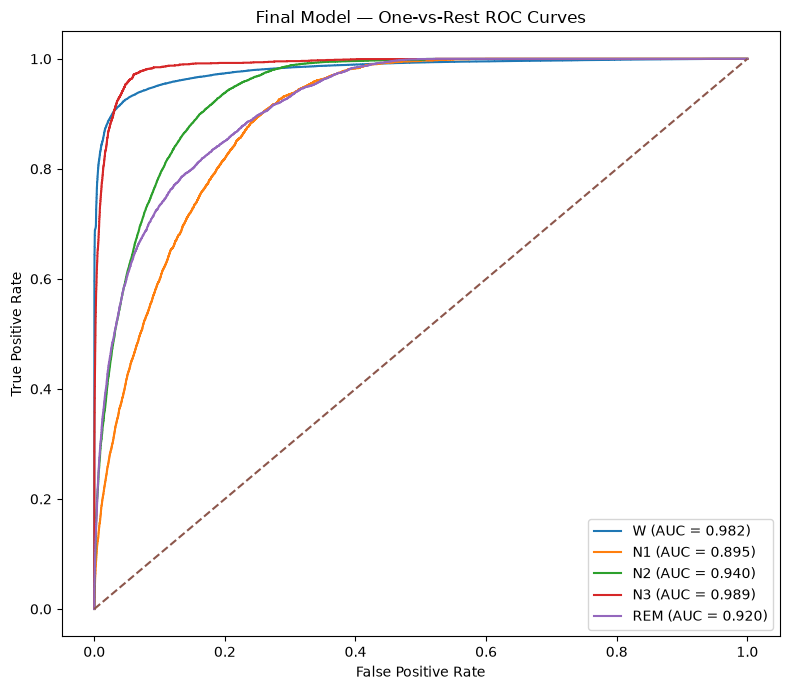

In [36]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

canonical_model = corrected_model_42

canonical_probabilities = (
    canonical_model.predict(
        X_test_best,
        batch_size=FINAL_BATCH_SIZE,
        verbose=1,
    )
)

fpr = {}
tpr = {}
roc_auc = {}

for i, class_name in enumerate(
    CLASS_NAMES
):

    fpr[i], tpr[i], _ = roc_curve(
        y_test_one_hot[:, i],
        canonical_probabilities[:, i],
    )

    roc_auc[i] = roc_auc_score(
        y_test_one_hot[:, i],
        canonical_probabilities[:, i],
    )

fig, ax = plt.subplots(
    figsize=(8, 7)
)

for i, class_name in enumerate(
    CLASS_NAMES
):

    ax.plot(
        fpr[i],
        tpr[i],
        label=(
            f"{class_name} "
            f"(AUC = {roc_auc[i]:.3f})"
        ),
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.set_title(
    "Final Model — One-vs-Rest ROC Curves"
)

ax.legend()

plt.tight_layout()
plt.show()

**Save the ROC-AUC results**

In [37]:
ROC_DIR = (
    PROJECT_ROOT
    / "results"
    / "final_evaluation"
    / "roc_auc"
)

ROC_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

roc_auc_results_df.to_csv(
    ROC_DIR
    / "roc_auc_per_seed.csv",
    index=False,
)

roc_auc_statistics.to_csv(
    ROC_DIR
    / "roc_auc_statistics.csv"
)

final_auc_table.to_csv(
    ROC_DIR
    / "final_auc_table.csv",
    index=False,
)

print(
    "ROC-AUC results saved to:"
)

print(
    ROC_DIR
)

ROC-AUC results saved to:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\results\final_evaluation\roc_auc


**Cohen's kappa**

In [38]:
from sklearn.metrics import cohen_kappa_score

kappa_results = []

for seed, model in corrected_seed_models.items():

    print("=" * 70)
    print(f"COHEN'S KAPPA — SEED {seed}")
    print("=" * 70)

    probabilities = model.predict(
        X_test_best,
        batch_size=FINAL_BATCH_SIZE,
        verbose=1,
    )

    predictions = np.argmax(
        probabilities,
        axis=1,
    )

    kappa = cohen_kappa_score(
        y_test_best,
        predictions,
    )

    kappa_results.append(
        {
            "seed": seed,
            "cohen_kappa": kappa,
        }
    )

kappa_results_df = pd.DataFrame(
    kappa_results
)

display(
    kappa_results_df.round(4)
)

COHEN'S KAPPA — SEED 42
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
COHEN'S KAPPA — SEED 123
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
COHEN'S KAPPA — SEED 456
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


,seed,cohen_kappa
0,42,0.6852
1,123,0.6794
2,456,0.6823


**Cohen's kappa — mean ± sd""**

In [39]:
kappa_mean = (
    kappa_results_df[
        "cohen_kappa"
    ].mean()
)

kappa_std = (
    kappa_results_df[
        "cohen_kappa"
    ].std(
        ddof=1
    )
)

kappa_min = (
    kappa_results_df[
        "cohen_kappa"
    ].min()
)

kappa_max = (
    kappa_results_df[
        "cohen_kappa"
    ].max()
)

print(
    f"Cohen's kappa: "
    f"{kappa_mean:.4f} ± {kappa_std:.4f}"
)

print(
    f"Range: "
    f"{kappa_min:.4f} – {kappa_max:.4f}"
)

Cohen's kappa: 0.6823 ± 0.0029
Range: 0.6794 – 0.6852


**Save Cohen's kappa**

In [40]:
kappa_results_df.to_csv(
    PROJECT_ROOT
    / "results"
    / "final_evaluation"
    / "cohen_kappa_per_seed.csv",
    index=False,
)

pd.DataFrame(
    {
        "metric": [
            "cohen_kappa"
        ],
        "mean": [
            kappa_mean
        ],
        "std": [
            kappa_std
        ],
        "min": [
            kappa_min
        ],
        "max": [
            kappa_max
        ],
    }
).to_csv(
    PROJECT_ROOT
    / "results"
    / "final_evaluation"
    / "cohen_kappa_statistics.csv",
    index=False,
)

print(
    "Cohen's kappa results saved."
)

Cohen's kappa results saved.


**Build the definitive results table**

In [43]:
import pandas as pd
import numpy as np
import json
from pathlib import Path


FINAL_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "final_evaluation"
)

FINAL_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Classification metrics
# ------------------------------------------------------------

classification_metrics = {
    "Accuracy": (
        corrected_seed_statistics.loc[
            "accuracy", "mean"
        ],
        corrected_seed_statistics.loc[
            "accuracy", "std"
        ],
    ),

    "Balanced Accuracy": (
        corrected_seed_statistics.loc[
            "balanced_accuracy", "mean"
        ],
        corrected_seed_statistics.loc[
            "balanced_accuracy", "std"
        ],
    ),

    "Macro Precision": (
        corrected_seed_statistics.loc[
            "macro_precision", "mean"
        ],
        corrected_seed_statistics.loc[
            "macro_precision", "std"
        ],
    ),

    "Macro Recall": (
        corrected_seed_statistics.loc[
            "macro_recall", "mean"
        ],
        corrected_seed_statistics.loc[
            "macro_recall", "std"
        ],
    ),

    "Macro F1": (
        corrected_seed_statistics.loc[
            "macro_f1", "mean"
        ],
        corrected_seed_statistics.loc[
            "macro_f1", "std"
        ],
    ),

    "Weighted F1": (
        corrected_seed_statistics.loc[
            "weighted_f1", "mean"
        ],
        corrected_seed_statistics.loc[
            "weighted_f1", "std"
        ],
    ),

    "Cohen's Kappa": (
        kappa_mean,
        kappa_std,
    ),

    "Macro ROC-AUC": (
        roc_auc_statistics.loc[
            "macro_roc_auc", "mean"
        ],
        roc_auc_statistics.loc[
            "macro_roc_auc", "std"
        ],
    ),

    "Weighted ROC-AUC": (
        roc_auc_statistics.loc[
            "weighted_roc_auc", "mean"
        ],
        roc_auc_statistics.loc[
            "weighted_roc_auc", "std"
        ],
    ),

    "Micro ROC-AUC": (
        roc_auc_statistics.loc[
            "micro_roc_auc", "mean"
        ],
        roc_auc_statistics.loc[
            "micro_roc_auc", "std"
        ],
    ),
}


def format_mean_std(mean, std):
    return f"{mean:.4f} ± {std:.4f}"


def metric_as_percentage(mean, std):
    return (
        f"{mean * 100:.2f}% ± "
        f"{std * 100:.2f}%"
    )


final_results_table = pd.DataFrame(
    [
        {
            "Metric": metric,
            "Mean": mean,
            "Std": std,
            "Mean ± SD": format_mean_std(
                mean,
                std,
            ),
        }
        for metric, (mean, std)
        in classification_metrics.items()
    ]
)


display(
    final_results_table
)

,Metric,Mean,Std,Mean ± SD
0,Accuracy,0.824012,0.002285,0.8240 ± 0.0023
1,Balanced Accuracy,0.653991,0.002418,0.6540 ± 0.0024
2,Macro Precision,0.666481,0.003993,0.6665 ± 0.0040
3,Macro Recall,0.653991,0.002418,0.6540 ± 0.0024
4,Macro F1,0.652592,0.000721,0.6526 ± 0.0007
5,Weighted F1,0.823350,0.001213,0.8234 ± 0.0012
6,Cohen's Kappa,0.682311,0.002880,0.6823 ± 0.0029
7,Macro ROC-AUC,0.944959,0.000145,0.9450 ± 0.0001
8,Weighted ROC-AUC,0.963447,0.000568,0.9634 ± 0.0006
9,Micro ROC-AUC,0.971814,0.000674,0.9718 ± 0.0007


**Create a thesis-friendly percentage table**

In [44]:
percentage_metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted F1",
]

thesis_results = final_results_table.copy()

thesis_results["Mean (%)"] = (
    thesis_results["Mean"] * 100
)

thesis_results["SD (%)"] = (
    thesis_results["Std"] * 100
)

thesis_results["Mean ± SD (%)"] = (
    thesis_results["Mean (%)"]
    .map(lambda x: f"{x:.2f}%")
    + " ± "
    + thesis_results["SD (%)"]
    .map(lambda x: f"{x:.2f}%")
)

display(
    thesis_results[
        [
            "Metric",
            "Mean ± SD (%)",
        ]
    ]
)

,Metric,Mean ± SD (%)
0,Accuracy,82.40% ± 0.23%
1,Balanced Accuracy,65.40% ± 0.24%
2,Macro Precision,66.65% ± 0.40%
3,Macro Recall,65.40% ± 0.24%
4,Macro F1,65.26% ± 0.07%
5,Weighted F1,82.34% ± 0.12%
6,Cohen's Kappa,68.23% ± 0.29%
7,Macro ROC-AUC,94.50% ± 0.01%
8,Weighted ROC-AUC,96.34% ± 0.06%
9,Micro ROC-AUC,97.18% ± 0.07%


**Final per-stage performance table**

In [49]:
per_stage_final = []

for stage in CLASS_NAMES:

    f1_mean = corrected_class_f1_summary.loc[
        corrected_class_f1_summary["Stage"] == stage,
        "Mean F1",
    ].iloc[0]

    f1_std = corrected_class_f1_summary.loc[
        corrected_class_f1_summary["Stage"] == stage,
        "Std F1",
    ].iloc[0]

    auc_mean = roc_auc_statistics.loc[
        f"{stage}_roc_auc",
        "mean",
    ]

    auc_std = roc_auc_statistics.loc[
        f"{stage}_roc_auc",
        "std",
    ]

    per_stage_final.append(
        {
            "Stage": stage,
            "F1 Mean": f1_mean,
            "F1 SD": f1_std,
            "F1 Mean ± SD":
                f"{f1_mean:.4f} ± {f1_std:.4f}",

            "ROC-AUC Mean": auc_mean,
            "ROC-AUC SD": auc_std,
            "ROC-AUC Mean ± SD":
                f"{auc_mean:.4f} ± {auc_std:.4f}",
        }
    )

per_stage_final_df = pd.DataFrame(
    per_stage_final
)

display(
    per_stage_final_df
)

,Stage,F1 Mean,F1 SD,F1 Mean ± SD,ROC-AUC Mean,ROC-AUC SD,ROC-AUC Mean ± SD
0,W,0.947222,0.001286,0.9472 ± 0.0013,0.981262,0.000679,0.9813 ± 0.0007
1,N1,0.341857,0.004511,0.3419 ± 0.0045,0.896394,0.000998,0.8964 ± 0.0010
2,N2,0.695728,0.002718,0.6957 ± 0.0027,0.938350,0.001483,0.9384 ± 0.0015
3,N3,0.730933,0.004533,0.7309 ± 0.0045,0.988279,0.000268,0.9883 ± 0.0003
4,REM,0.547217,0.002348,0.5472 ± 0.0023,0.920511,0.000648,0.9205 ± 0.0006


**Final confusion matrix from the canonical seed**

[[41671   673  1458    80   674]
 [  590  1191  1826    34   881]
 [  619   425  9732   384  1385]
 [   50     0   650  1708    14]
 [  380   254  1665    14  3181]]


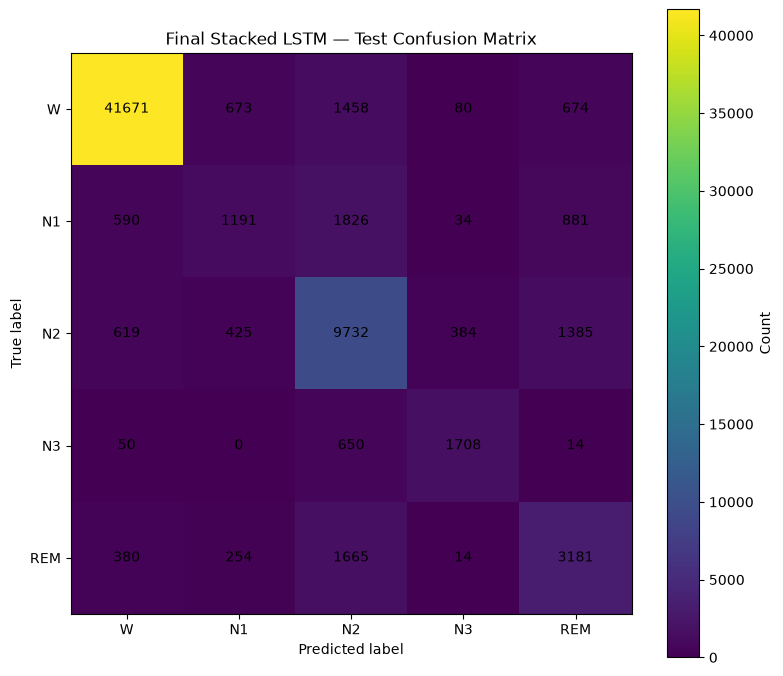

In [50]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


canonical_probabilities = (
    corrected_model_42.predict(
        X_test_best,
        batch_size=FINAL_BATCH_SIZE,
        verbose=0,
    )
)

canonical_predictions = np.argmax(
    canonical_probabilities,
    axis=1,
)

canonical_confusion_matrix = (
    confusion_matrix(
        y_test_best,
        canonical_predictions,
    )
)

print(
    canonical_confusion_matrix
)


fig, ax = plt.subplots(
    figsize=(8, 7)
)

im = ax.imshow(
    canonical_confusion_matrix,
)

ax.set_xticks(
    range(len(CLASS_NAMES))
)

ax.set_yticks(
    range(len(CLASS_NAMES))
)

ax.set_xticklabels(
    CLASS_NAMES
)

ax.set_yticklabels(
    CLASS_NAMES
)

ax.set_xlabel(
    "Predicted label"
)

ax.set_ylabel(
    "True label"
)

ax.set_title(
    "Final Stacked LSTM — Test Confusion Matrix"
)

for i in range(
    len(CLASS_NAMES)
):

    for j in range(
        len(CLASS_NAMES)
    ):

        ax.text(
            j,
            i,
            canonical_confusion_matrix[
                i,
                j,
            ],
            ha="center",
            va="center",
        )

plt.colorbar(
    im,
    ax=ax,
    label="Count",
)

plt.tight_layout()
plt.show()

**Save everything in one final-results folder**

In [55]:
# Overall metrics
final_results_table.to_csv(
    FINAL_RESULTS_DIR
    / "final_overall_metrics.csv",
    index=False,
)

# Thesis-friendly table
thesis_results.to_csv(
    FINAL_RESULTS_DIR
    / "final_overall_metrics_percent.csv",
    index=False,
)

# Per-stage metrics
per_stage_final_df.to_csv(
    FINAL_RESULTS_DIR
    / "final_per_stage_metrics.csv",
    index=False,
)

# Confusion matrix
pd.DataFrame(
    canonical_confusion_matrix,
    index=CLASS_NAMES,
    columns=CLASS_NAMES,
).to_csv(
    FINAL_RESULTS_DIR
    / "final_confusion_matrix.csv"
)

# Seed results
corrected_seed_results_df.to_csv(
    FINAL_RESULTS_DIR
    / "seed_results.csv",
    index=False,
)

corrected_seed_statistics.to_csv(
    FINAL_RESULTS_DIR
    / "seed_statistics.csv"
)

# Kappa
kappa_results_df.to_csv(
    FINAL_RESULTS_DIR
    / "cohen_kappa_per_seed.csv",
    index=False,
)

# ROC-AUC
roc_auc_results_df.to_csv(
    FINAL_RESULTS_DIR
    / "roc_auc_per_seed.csv",
    index=False,
)

roc_auc_statistics.to_csv(
    FINAL_RESULTS_DIR
    / "roc_auc_statistics.csv"
)

# Configuration
with open(
    FINAL_RESULTS_DIR
    / "final_configuration.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        DEFINITIVE_CONFIG,
        file,
        indent=4,
    )

print(
    "All final evaluation artifacts saved to:"
)

print(
    FINAL_RESULTS_DIR
)

All final evaluation artifacts saved to:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\results\final_evaluation


**Create the definitive experiment record**

In [56]:
definitive_record = {
    "dataset": {
        "name": "Sleep-EDF Expanded",
        "recordings": 197,
        "participants": 100,
        "eeg_channel": "EEG Fpz-Cz",
        "sampling_frequency_hz": 100.0,
    },

    "split": {
        "unit": "participant",
        "train_participants": 70,
        "validation_participants": 15,
        "test_participants": 15,
        "participant_leakage": 0,
    },

    "features": FEATURE_COLUMNS,

    "epoch": {
        "duration_seconds": 30,
    },

    "temporal_context": {
        "sequence_length_epochs": 10,
        "duration_minutes": 5.0,
    },

    "model": {
        "architecture": "stacked_lstm",
        "lstm_units": [32, 32],
        "dropout": 0.30,
    },

    "training": {
        "loss": (
            "unweighted_sparse_categorical_crossentropy"
        ),
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "batch_size": 256,
        "max_epochs": 30,
        "random_seeds": [42, 123, 456],
    },

    "selection": {
        "criterion": "validation_macro_f1",
        "temporal_context": "5 minutes",
        "loss_strategy": "unweighted",
        "lstm_units": 32,
        "architecture": "stacked",
    },

    "test_results": {
        "accuracy": {
            "mean": float(
                corrected_seed_statistics.loc[
                    "accuracy",
                    "mean",
                ]
            ),
            "std": float(
                corrected_seed_statistics.loc[
                    "accuracy",
                    "std",
                ]
            ),
        },

        "balanced_accuracy": {
            "mean": float(
                corrected_seed_statistics.loc[
                    "balanced_accuracy",
                    "mean",
                ]
            ),
            "std": float(
                corrected_seed_statistics.loc[
                    "balanced_accuracy",
                    "std",
                ]
            ),
        },

        "macro_f1": {
            "mean": float(
                corrected_seed_statistics.loc[
                    "macro_f1",
                    "mean",
                ]
            ),
            "std": float(
                corrected_seed_statistics.loc[
                    "macro_f1",
                    "std",
                ]
            ),
        },

        "weighted_f1": {
            "mean": float(
                corrected_seed_statistics.loc[
                    "weighted_f1",
                    "mean",
                ]
            ),
            "std": float(
                corrected_seed_statistics.loc[
                    "weighted_f1",
                    "std",
                ]
            ),
        },

        "cohen_kappa": {
            "mean": float(kappa_mean),
            "std": float(kappa_std),
        },

        "macro_roc_auc": {
            "mean": float(
                roc_auc_statistics.loc[
                    "macro_roc_auc",
                    "mean",
                ]
            ),
            "std": float(
                roc_auc_statistics.loc[
                    "macro_roc_auc",
                    "std",
                ]
            ),
        },
    },
}


DEFINITIVE_RECORD_PATH = (
    FINAL_RESULTS_DIR
    / "definitive_experiment_record.json"
)

with open(
    DEFINITIVE_RECORD_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        definitive_record,
        file,
        indent=4,
    )

print(
    "Definitive experiment record saved:"
)

print(
    DEFINITIVE_RECORD_PATH
)

Definitive experiment record saved:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\results\final_evaluation\definitive_experiment_record.json
